# Mean Reversion Strategy

This strategy, in some sense, is the opposite of momentum strategies. If a financial product has performed too well relative to its trend, then it is shorted and vice versa.

Working, again, with bitcoin, the idea is to define a threshold for the distance between the current stock price and the SMA, which signals long and short positions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.read_prices import read_parquet
from utils.metrics import Metrics as m

In [2]:
df = read_parquet()
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


In [3]:
df_copy = df.copy()

In [4]:
SMA = 25
threshold = 2000 ## absolute deviation of the current price to deviate from the SMA

df_copy['SMA'] = df_copy['Close'].rolling(SMA).mean()
df_copy['distance'] = df_copy['Close'] - df_copy['SMA']

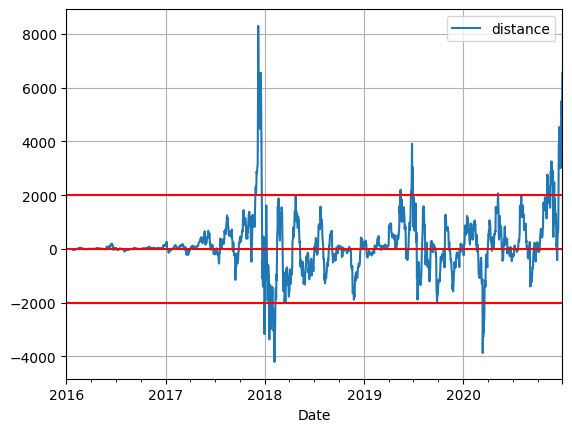

In [5]:
df_copy[["distance"]].plot(kind="line", legend=True)
plt.axhline(0, color='r')
plt.axhline(threshold, color='r')
plt.axhline(-threshold, color='r')
plt.grid(.4)
plt.show()

In [6]:
df_copy["position"] = np.where(df_copy["distance"] > threshold, -1, np.nan)
df_copy["position"] = np.where(df_copy["distance"] < -threshold, 1, df_copy["position"])
df_copy["position"] = np.where(df_copy["distance"] * df_copy["distance"].shift(1) < 0, 0, df_copy["position"])

df_copy["position"] = df_copy["position"].ffill().fillna(0)

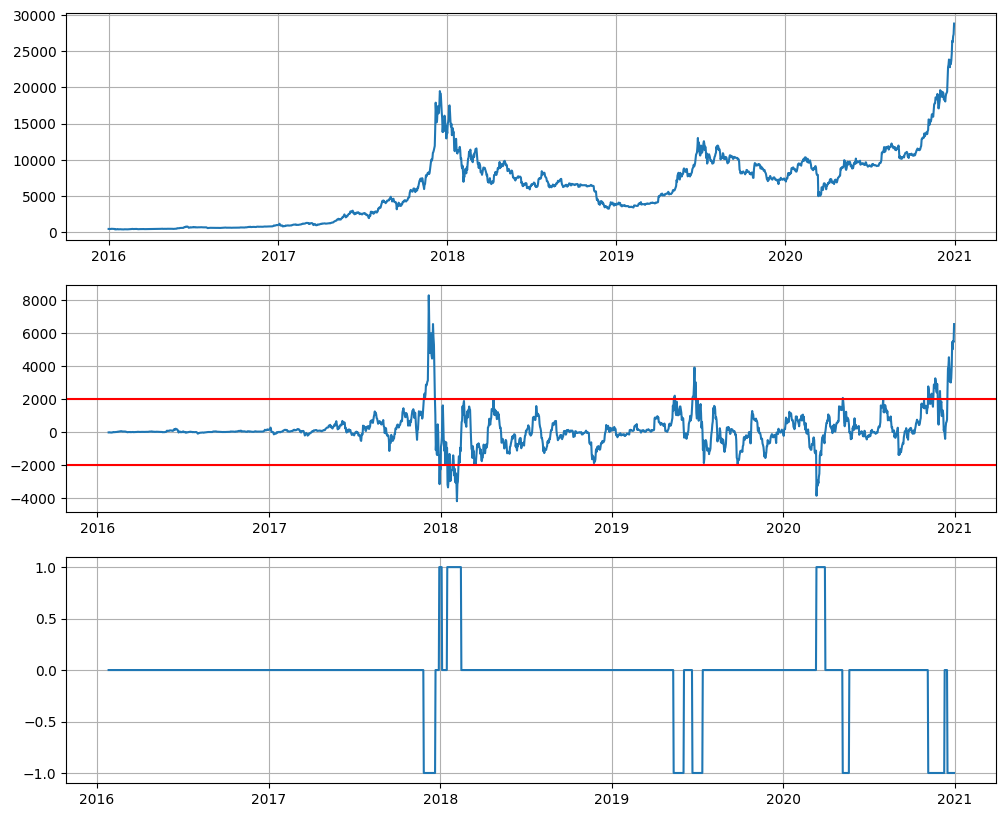

In [7]:
fig, ax = plt.subplots(3,1, figsize=(12,10))
ax[0].plot(df_copy["Close"])
ax[0].grid(.4)

ax[1].plot(df_copy["distance"])
ax[1].axhline(threshold, c="r")
ax[1].axhline(-threshold, c="r")
ax[1].grid(.4)

ax[2].plot(df_copy["position"].iloc[SMA:])
ax[2].grid(.4)

In [8]:
df_copy["strategy"] = df_copy["position"].shift(1) * df_copy["log_returns"]

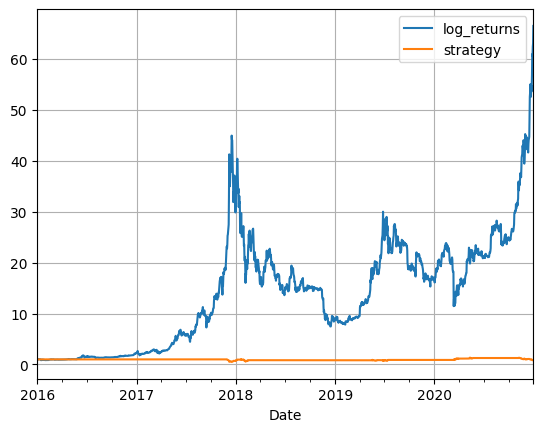

In [9]:
np.exp(df_copy[["log_returns", "strategy"]].cumsum()).plot(kind="line")
plt.grid(.4)
plt.show()

In [10]:
thresholds = np.linspace(25, 2000, 8)
# thresholds.append(thresholds)

# threshold_strategies = [df_copy['log_returns']]
threshold_strategies = []

for i in thresholds:
    df = df_copy.copy()

    df['SMA'] = df['Close'].rolling(SMA).mean()
    df['distance'] = df['Close'] - df['SMA']
    df.dropna()

    ## strategy of buying/selling given the threshold
    df['position'] = np.where(df['distance'] > i, -1, np.nan)

    df['position'] = np.where(df['distance'] < -i,
                                1, df['position'])

    df['position'] = np.where(df['distance'] * df['distance'].shift(1) < 0, 0, df['position'])

    df['position'] = df['position'].ffill().fillna(0)

    strategy = df['position'].shift(1) * df['log_returns']
    strategy = strategy.dropna()

    threshold_strategies.append(strategy)

In [11]:
thresholds = thresholds.tolist()

In [12]:
thresholds.insert(0, 0)

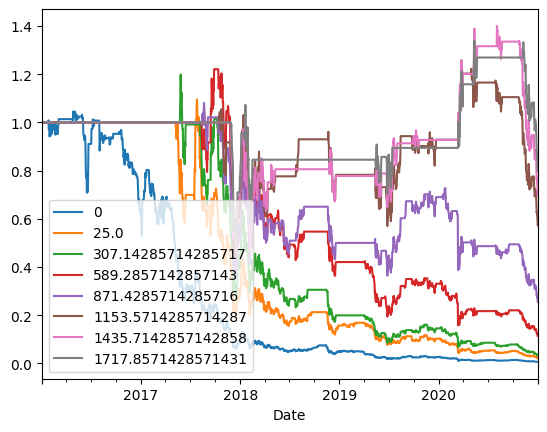

In [13]:
for (strategy,
    threshold,
    ) \
        in zip(
    threshold_strategies,
    thresholds,
    ):
    np.exp(strategy.cumsum()).plot(kind='line',
                                   label=f"{threshold}",
                                   )

plt.legend()
plt.show()

In [14]:
np.exp(df_copy["log_returns"])

Date
2016-01-01         NaN
2016-01-02    0.997937
2016-01-03    0.992093
2016-01-04    1.007163
2016-01-05    0.997389
                ...   
2020-12-26    1.071853
2020-12-27    0.993769
2020-12-28    1.030927
2020-12-29    1.010250
2020-12-30    1.054034
Name: log_returns, Length: 1826, dtype: float64

In [15]:
mr_strat_annual_ret = m.annualized_return(np.exp(df_copy["strategy"]))
mr_terminal_ret = m.terminal_return(df_copy["strategy"])

print(f"Mean Reversion Terminal Return: {mr_terminal_ret}")
print(f"Mean Reversion Annualized Returns: {mr_strat_annual_ret}")

Mean Reversion Terminal Return: -0.20013799523899578
Mean Reversion Annualized Returns: -0.04365710404015011


In [19]:
from utils.backtest import MeanReversion

In [20]:
mr_backtest = MeanReversion("BTC-USD",
                            "2021-01-01",
                            "2025-12-31",
                            amount=1000)

cumrets, cumstrat = mr_backtest.strategy(sma=25, threshold=2000)

cumrets, cumstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(2256.6), np.float64(1104.73))

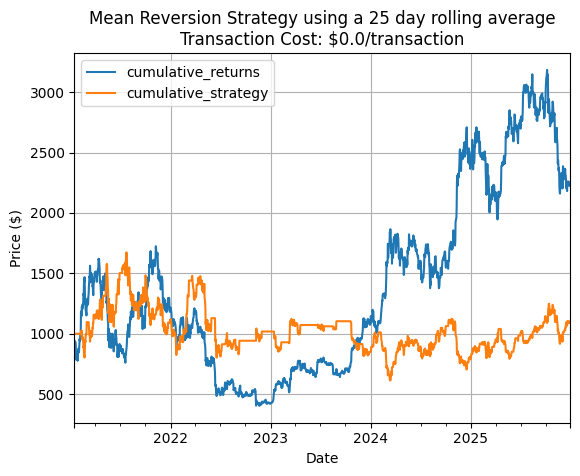

In [21]:
mr_backtest.plot_strategy()

In [22]:
mr_backtest.get_terminal_return(), mr_backtest.get_drawdown()

((1.26, 0.1), (np.float64(-0.29239773353113), np.float64(-0.6331856991155593)))

In [23]:
mr_backtest_fee = MeanReversion("BTC-USD",
                            "2021-01-01",
                            "2025-12-31",
                            trans_cost=.36,
                            amount=1000)

cumrets, cumstrat = mr_backtest_fee.strategy(sma=25, threshold=1000)

cumrets, cumstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(2256.6), np.float64(481.35))

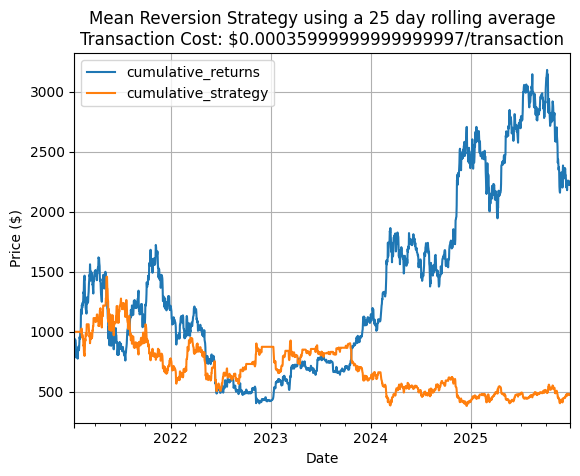

In [24]:
mr_backtest_fee.plot_strategy()

In [25]:
mr_backtest_fee.get_drawdown()

(np.float64(-0.29239773353113), np.float64(-0.7381858657075886))